# Practical ADMET model training - when does it work?



<img src="./img/the_caco2.png" width="600">

*Dr Maria Castellanos*

## OMSF 2026 Demo

Hi all, and welcome to the 2026 OpenADMET Demo! Here we will show an example of using our stack to do some training and finetuning on ChEMBL and the [ExpansionRx dataset](https://huggingface.co/spaces/openadmet/OpenADMET-ExpansionRx-Challenge) from our most recent blind challenge. This is an adaptation of some of the tutorials available at our [demos repo](https://demos.openadmet.org). Check it out for more detailed deep dives.

Our aim is to show in practice how one might use the OpenADMET stack to approach a **tangible set of program data**, some of the relevant pitfalls and how to finetune to optimise performance on your own programs. 




## The ExpansionRx dataset

Here we will use the ExpansionRx dataset as a test bed, the largest public ADMET dataset released to date from a real drug discovery program. It covers more than 7,500 compounds across 9 ADME assays collected over ~5 years for Expansion Therapeutics' programs in RNA-mediated and neurodegenerative diseases. This gives us a **realistic** program dataset to benchmark on across a full assay cascade in a focused chemical space.


<img src="img/expansion.png" width="600">


## Setting the stage

Consider this scenario: you have just started a new drug program and you want to use a model to predict certain ADMET endpoints to guide compound prioritisation. **There are several approaches you might take:**

* (1) Use **zero-shot models** — pre-existing models already available in the public domain
* (2) Train your own model on **public data** — leverage publicly available data yourself
* (3) Train a model on **both public data and your own program data** — combine public data with proprietary measurements

We will walk through each approach and evaluate performance against the ExpansionRx canonical test-train split.


## Zero-Shot / Global models

Something you might try first is to use some **off-the shelf** pre-existing models. These models are in the public domain (often with webservers) and are the lowest-overhead way to get ADMET predictions. We will call this **zero-shot** or **global model** prediction. In this case, these public models are trained on data curated by the authors that is unlikely to contain the chemistry of interest.

How likely is this to work? 

We will cover two popular webserver implementations 

* ADMET-AI, a ChemProp v1 GNN enhanced with RDKit descriptors trained on data from the Therapeutic Data Commons (TDC), available as a [web-based tool](https://admet.ai.greenstonebio.com/?ref=openadmet.ghost.io).

* ADMETLab 3.0 similarly is a ChemProp v1 model trained on 400,000 molecules curated from ChEMBL, PubChem and OCHEM. It's available at this web server [here](https://admetlab3.scbdd.com/?ref=openadmet.ghost.io).

## Starting with an easy endpoint: LogD

LogD is considered a relatively "learnable" endpoint due to its additive nature and strong correlation with computable quantities (cLogP and other descriptors). How does ADMETLab3 perform on the ExpansionRx LogD test set?

<img src="img/ADMETLab3_LogD.png" width="600">

Performance is poor for a learnable property. There is substantial scatter, and the model shows clear systematic bias across the activity range. This is representative of what we typically see with zero-shot models on program data.


## Training on public data with Anvil

Much of the focus in our field has been on model architectures, but data quality and curation have an equally important role. It is worth asking whether a well-curated public dataset, trained with a rigorous pipeline can outperform existing zero-shot tools.

With this in mind, OpenADMET has trained a series of public-data models available on [HuggingFace](https://huggingface.co/openadmet). These are trained primarily on data curated from ChEMBL and serve as our **best-effort zero-shot models** built with the OpenADMET stack.



<div style="background:light-dark(#fff8e1, #2d2a1f); color:light-dark(#333, #e8e6e0); border-left:5px solid #f9a825; padding:14px 18px; border-radius:6px; margin:16px 0;">
<b>🤖 Anvil — our workflow engine</b><br><br>
We use our  <a href="https://github.com/OpenADMET/openadmet_models"><b>Anvil model training harness</b></a>. to train models reproducibly for public use, combining it with our pre-curated  <a href="https://github.com/OpenADMET/data-catalogs"><b>ChEMBL data catalogs</b></a> You can reproduce exactly what we have done very easily!
</div>



In [1]:
# Read pre-curated data from our `data-catalogs` repo, more detail about reference code used to curate in our demos repo
# https://demos.openadmet.org

import intake
import pandas as pd

try:
    cat = intake.open_catalog(
        "https://github.com/OpenADMET/data-catalogs/raw/refs/heads/main/catalogs/activities/ChEMBL_LogD/CATALOG_ChEMBL35_LogD.yaml"
    )
    chembl_logd = cat["LogD_aggregated"].read()
except Exception:
    # Fall back to local pre-downloaded copy when S3 is unavailable
    chembl_logd = pd.read_csv("data/chembl_logD.csv")

chembl_logd.reset_index(drop=True).head()

,OPENADMET_CANONICAL_SMILES,OPENADMET_INCHIKEY,assay_id_count,standard_value_mean,standard_value_median,standard_value_std,pchembl_value_mean,pchembl_value_median,pchembl_value_std
0,CC(C)NCC(O)COC1=CC=CC2=CC=CC=C12,AQHHHDLHHXJYJD-UHFFFAOYSA-N,25,1.030800,1.220,0.452124,NaN,NaN,NaN
1,CCN(CC)CCCC(C)NC1=CC=NC2=CC(Cl)=CC=C12,WHTVZRBIWZFKQO-UHFFFAOYSA-N,19,0.404444,0.850,1.576232,NaN,NaN,NaN
2,CNCCCN1C2=CC=CC=C2CCC2=CC=CC=C21,HCYAFALTSJYZDH-UHFFFAOYSA-N,15,1.749267,1.100,2.382542,NaN,NaN,NaN
3,CN(C)CCCN1C2=CC=CC=C2CCC2=CC=CC=C21,BCGWQEUPMDMJNV-UHFFFAOYSA-N,15,1.948067,2.400,1.223295,NaN,NaN,NaN
4,COCCC1=CC=C(OCC(O)CNC(C)C)C=C1,IUBSYMUCCVWXPE-UHFFFAOYSA-N,14,-0.500714,-0.305,0.714363,NaN,NaN,NaN


Now, using the data we have curated, let's train a model with Anvil! We use YAML config files to define simple training configurations. Here, we are training a CheMeleon, foundation-based GNN on LogD data (some additional curation from the above). Lets have a quick look at one of these YAML files. 

While this looks a bit complicated, provide an easily configurable library of these along with an extensive set of [documentation](https://docs.openadmet.org) and [demos](https://demos.openadmet.org)

<div style="background:light-dark(#fff8e1, #2d2a1f); color:light-dark(#333, #e8e6e0); border-left:5px solid #f9a825; padding:14px 18px; border-radius:6px; margin:16px 0;">
<b>🤖 Optimus Prime — our canonical recipe library</b><br><br>
We keep all of our canonical recipes in a repo called <a href="https://github.com/OpenADMET/optimus-prime"><b>Optimus Prime</b></a>. We have optimized hyperparameters over several datasets to arrive at reasonable defaults — these recipes are re-usable and easily configurable.
</div>

In [2]:
import yaml

with open("./LogD_anvil_train/chemeleon_single_one_epoch.yaml", "r") as f:
    data = yaml.safe_load(f)

```yaml
# Section specifying input data
data:
  # Specify the dataset file, can be S3 path etc.
  resource: {{ANVIL_DIR}}/logd_data.csv
  # must be intake
  type: intake
  # Specify input column containing SMILES
  input_col: OPENADMET_CANONICAL_SMILES
  # Specify whether or not to drop NaN data rows
  dropna: False
  # Specify each (1+) of the target columns
  target_cols:
  - logD

# Additional metadata
metadata:
  authors: Maria A. Castellanos
  email: maria.castellanos@omsf.io
  biotargets:
  - LogD
  build_number: 0
  description: basic regression using a ChemProp multitask task model
  driver: pytorch
  name: chemprop_logD_single_task
  tag: chemprop
  tags:
  - openadmet
  - example
  - chemprop
  version: v1

# Section specifying training procedure
procedure:
  # Featurization specification
  feat:
    # Using the ChemPropFeaturizer (for ChemProp model)
    # See openadmet.models.features
    type: ChemPropFeaturizer
    params:
      batch_size: 128
      normalize_targets: true
      n_jobs: 4
  
  # Model specification
  model:
    # Indicate model type
    # See openadmet.models.architecture
    type: ChemPropModel
    # Specify model parameters
    params:
      ffn_hidden_dim: 512
      ffn_hidden_num_layers: 3
      mpnn_lr: 1e-4
      ffn_lr: 1e-3
      mpnn_weight_decay: 0
      ffn_weight_decay: 1e-4
      dropout: 0.25
      batch_norm: False
      scheduler: plateau
      reduce_lr_patience: 5
      reduce_lr_factor: 0.5
      n_tasks: 1 # Number of tasks should match the number of target columns
      from_foundation: "chemeleon" # use the pre-trained Chemeleon model, will overwrite the model parameters except FFN

  # Specify data splits
  split:
    # Specify how data will be split, can be ShuffleSplitter, ScaffoldSplitter, etc.
    # See openadmet.models.split
    type: ShuffleSplitter
    # Specify split parameters
    params:
      random_state: 42
      train_size: 0.7
      val_size: 0.1
      test_size: 0.2
    
  # Specify training configuration
  train:
    # Specify the trainer, here LightningTrainer as ChemProp is a PyTorch Lightning model
    # See openadmet.models.trainer
    type: LightningTrainer
    # Specify model parameters
    params:
      accelerator: gpu
      monitor_metric: val_loss
      gradient_clip_val: 0.5
      early_stopping: true
      early_stopping_patience: 20
      early_stopping_mode: min
      early_stopping_min_delta: 0.001
      max_epochs: 50
      use_wandb: false
      wandb_project: chemeleon_permeability # Specify wandb project name according to guidelines

# Section specifying report generation
report:
  # Configure evaluation
  eval:
  # Generate regression metrics
  - type: RegressionMetrics
    params: {}
  # Generate regression plots & do cross validation, will write out stats to the report directory
  - type: PytorchLightningRepeatedKFoldCrossValidation
    params:
      axes_labels:
      - True LogPapp
      - Predicted LogPapp
      n_repeats: 5
      n_splits: 5
      random_state: 42
      pXC50: true
      title: Multitask True vs Predicted LogPapp on test set
```

The sharp-eyed among you will see that we cover the typical, configureable decisions you would make when training a machine learning model. 

* Input data
* Splitting algorithm and ratios
* Molecular representation
* Model and hyperparameters
* Evaluation and CV

We can read this into a workflow (or construct in code directly).

In [3]:
from openadmet.models.anvil.specification import AnvilSpecification

spec = AnvilSpecification.from_recipe("./LogD_anvil_train/chemeleon_single_one_epoch.yaml")
spec

AnvilSpecification(metadata=Metadata(version='v1', driver='pytorch', name='chemprop_pchembl', build_number=0, description='basic regression using a ChemProp multitask task model', tag='chemprop', authors='Maria A. Castellanos', email='maria.castellanos@omsf.io', biotargets=['LogD'], tags=['openadmet', 'example', 'chemprop']), data=DataSpec(type='intake', resource='file:///store/projects/OpenADMET/omsf_con_2026_demo/01_train_and_finetune_CPU_demo/LogD_anvil_train/logd_data.csv', cat_entry=None, target_cols=['logD'], input_col='OPENADMET_CANONICAL_SMILES', anvil_dir='file:///store/projects/OpenADMET/omsf_con_2026_demo/01_train_and_finetune_CPU_demo/LogD_anvil_train', dropna=False, train_resource=None, test_resource=None, val_resource=None), procedure=ProcedureSpec(split=SplitSpec(type='ShuffleSplitter', params={'random_state': 42, 'train_size': 0.7, 'val_size': 0.1, 'test_size': 0.2}), feat=FeatureSpec(type='ChemPropFeaturizer', params={'batch_size': 128, 'normalize_targets': True, 'n_jo

In [4]:
# Running the workflow!
spec.to_workflow()

2026-06-09 14:55:47.652 | INFO     | openadmet.models.anvil.specification:to_workflow:736 - Making workflow from specification
/home/hmacdope/mambaforge/envs/openadmet_models7/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AnvilDeepLearningWorkflow(metadata=Metadata(version='v1', driver='pytorch', name='chemprop_pchembl', build_number=0, description='basic regression using a ChemProp multitask task model', tag='chemprop', authors='Maria A. Castellanos', email='maria.castellanos@omsf.io', biotargets=['LogD'], tags=['openadmet', 'example', 'chemprop']), data_spec=DataSpec(type='intake', resource='file:///store/projects/OpenADMET/omsf_con_2026_demo/01_train_and_finetune_CPU_demo/LogD_anvil_train/logd_data.csv', cat_entry=None, target_cols=['logD'], input_col='OPENADMET_CANONICAL_SMILES', anvil_dir='file:///store/projects/OpenADMET/omsf_con_2026_demo/01_train_and_finetune_CPU_demo/LogD_anvil_train', dropna=False, train_resource=None, test_resource=None, val_resource=None), transform=None, split=ShuffleSplitter(train_size=0.7, val_size=0.1, test_size=0.2, random_state=42), feat=ChemPropFeaturizer(normalize_targets=True, n_jobs=4, batch_size=128, shuffle=False), model=ChemPropModel(n_tasks=1, messages='bond', 

In [5]:
%set_env OADMET_NO_RICH_LOGGING=1

env: OADMET_NO_RICH_LOGGING=1


We can run this  directly with the `Anvil` CLI (including the workflow construction step)

**we just do a single epoch here to avoid taking ages training our model**

In [6]:

!openadmet anvil --recipe-path LogD_anvil_train/chemeleon_single_one_epoch.yaml --output-dir LogD_anvil_train/chembl_chemeleon_my_training

Workflow initialized successfully with recipe: LogD_anvil_train/chemeleon_single_one_epoch.yaml
2026-06-09 14:55:51.639 | INFO     | openadmet.models.anvil.specification:to_workflow:736 - Making workflow from specification
2026-06-09 14:55:53.641 | INFO     | openadmet.models.anvil.workflow:run:747 - Running workflow from directory LogD_anvil_train/chembl_chemeleon_my_training_2026-06-09_aeea6a
2026-06-09 14:55:53.641 | INFO     | openadmet.models.anvil.workflow:run:750 - Running with driver lightning
2026-06-09 14:55:53.641 | INFO     | openadmet.models.anvil.workflow:run:753 - Loading data
2026-06-09 14:55:53.665 | INFO     | openadmet.models.anvil.specification:_read_single_resource:268 - 22806 total rows. 0 NaN rows were dropped.
2026-06-09 14:55:53.666 | INFO     | openadmet.models.anvil.workflow:run:763 - Splitting data from single resource
2026-06-09 14:55:53.669 | INFO     | openadmet.models.anvil.workflow:run:767 - Data loaded
2026-06-09 14:55:53.693 | INFO     | openadmet.mod

**We can then predict on the ExpansionRx test set!**

We have pre-prepared a model for you as training here would take some time.

In [7]:
!openadmet predict \
    --input-path data/exprx_test.csv \
    --input-col OPENADMET_CANONICAL_SMILES \
    --model-dir LogD_anvil_train/chembl_chemeleon \
    --output-csv exprx_chembl_logd_predictions.csv \
    --accelerator cpu


2026-06-09 15:02:08.723 | INFO     | openadmet.models.inference.inference:predict:177 - Starting prediction
2026-06-09 15:02:08.723 | INFO     | openadmet.models.inference.inference:predict:178 - Input path: data/exprx_test.csv
2026-06-09 15:02:08.723 | INFO     | openadmet.models.inference.inference:predict:179 - Model directories: ('LogD_anvil_train/chembl_chemeleon',)
2026-06-09 15:02:08.723 | INFO     | openadmet.models.inference.inference:predict:180 - Write CSV: True
2026-06-09 15:02:08.723 | INFO     | openadmet.models.inference.inference:predict:181 - Output CSV: exprx_chembl_logd_predictions.csv
2026-06-09 15:02:08.723 | INFO     | openadmet.models.inference.inference:predict:182 - Input column: OPENADMET_CANONICAL_SMILES
2026-06-09 15:02:08.723 | INFO     | openadmet.models.inference.inference:predict:183 - Accelerator: cpu
2026-06-09 15:02:08.725 | INFO     | openadmet.models.inference.inference:predict:209 - Model directories: ('LogD_anvil_train/chembl_chemeleon',)
2026-06-

This is how we train almost all our models at OpenADMET, and the format in which they are released on HuggingFace. You can, of course, still use them with the underlying library (`ChemProp`, `scikit-learn`)

<div style="background:light-dark(#fff8e1, #2d2a1f); color:light-dark(#333, #e8e6e0); border-left:5px solid #f9a825; padding:14px 18px; border-radius:6px; margin:16px 0;">
<b>🤖 HuggingFace — home of our baseline global ADMET models (with caveats)</b><br><br>
We stage public-data models that we have trained on <a href="https://huggingface.co/openadmet"><b>HuggingFace</b></a>. There models are our best effort baselines but suffer from the same issues explored in this blog post. 
</div>


Our actual **public data baseline** model that we released on [HuggingFace](https://huggingface.co/openadmet) uses **multitasking** in a set of related endpoints (often called **task-affinity grouping**) for slightly better performance as well as some stricter curation of the data presented above (for outliers and similer). The recipe used for this model is in the `LogD_anvil_train` folder as `chemeleon_multi.yaml` and performance of this model is shown below. Full instructions for using this (and other) models are provided on HuggingFace and later below.

<img src="img/OADMET_LogD.png" width="600">

This is better than ADMET-AI model above, showing that execution is important. But, this still leaves a lot on the table relative to what you can do with training on actual data from the program!

BONUS, use the model we have on HuggingFace via Docker

```bash
git clone https://huggingface.co/permeability-logd-ppb-chemeleon-baseline/ && cd permeability-logd-ppb-chemeleon-baseline
git lfs install && git lfs pull

docker run -it --user=root --rm  \
   -v ./permeability-logd-ppb-chemeleon-baseline:/home/mambauser/model:rw \
   --runtime=nvidia \
   --gpus \
   all ghcr.io/openadmet/openadmet-models:main

# INSIDE the container run an example
cd /home/mambauser/model
./run_model_inference.sh
```


## Zero-shot / Global performance across a variety of endpoints

We have evaluated zero-shot model performance across all endpoints where predictions are available from the public tools.

The plot below shows performance on the ExpansionRx test set for each endpoint and model. For context, we overlay results from the **ExpansionRx blind challenge** — over **400 participants** trained models on the ExpansionRx training set and submitted predictions. We include the challenge winner (`pebble`) and an LGBM baseline (RDKit fingerprints + descriptors) trained on the training set.



Zooming in on LogD first, we compare zero-shot models directly against models trained on the ExpansionRx training set. `pebble` is the challenge winner; the LGBM baseline uses RDKit fingerprints and descriptors trained on the same program data.

<img src="img/pebble_LogD.png" width="600">

Pebble's model is much much better than our "better-executed" public data models (they also have a consortium and their own proprietary data), but it gets even more surprising. Even a simple LGBM baseline trained on program data handily outperforms most zero-shot models. The full picture across all nine endpoints is below.

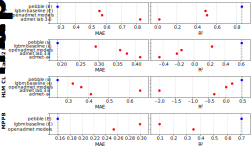

In [8]:
from IPython.display import SVG

SVG(filename="./img/anova_zero_shot.svg")

**Key things to note:**

- Zero-shot models consistently underperform models trained on program data
- The LGBM baseline trained on program data beats all zero-shot models across nearly every endpoint, despite much more intensive training and a much larger number of parameters.

## Global ADMET models are not sufficient for program-level prediction

The results are clear: Global models do not generalise well to program data. While our ChEMBL-trained implementation shows some improvement over other public-data implementations, the core finding holds **data is the key to good performance**.

<div style="background:light-dark(#fdecea, #3d1a15); color:light-dark(#333, #e8d0d0); border-left:5px solid #c62828; padding:14px 18px; border-radius:6px; margin:16px 0; font-size:1.1em;">
<b>⚠️ Algorithm complexity cannot rescue you from a lack of data.</b><br><br>
While there is some dependence on how your program relates to existing assayed chemical space, for most ADMET endpoints the sparsity of data makes this a moot point. We believe people acknowledge this uncomfortable truth enough.
</div>

This is key to our philosophy at OpenADMET — we as a community need to collect much more data and apply the rigorous techniques of drug discovery to anti-targets.

## Where we are going?

We have many unanswered questions we'd like to pursue:

* How much program data is actually needed?
* Are there easy ways to identifiy if your model is in or out of domain?
* Can we boost performance with foundation models? How to best construct them?
* How can we collect data in the most efficent way?

Look for more from OpenADMET soon in these areas!

# Fine-tuning to your program

The analysis above establishes the baseline: to get useful predictions, in most cases you need to incorporate program data. The question then becomes *how* to do this efficiently.

OpenADMET supports fine-tuning a pre-trained public-data model on your own measurements. The idea is to use the broad chemical knowledge encoded in a large ChEMBL-trained model as a starting point, then adapt to your program's specific chemistry. This is typically more efficient than training from scratch, which is data-hungry and often leads to overfitting when you only have a few hundred program measurements.

To demonstrate this we will work through **HLM clearance** — human liver microsomal intrinsic clearance. HLM reports how efficiently cytochrome P450 enzymes metabolise a compound, and low clearance is a key prerequisite for oral drugs. It is also a substantially harder endpoint than LogD. Clearance depends on specific substrate-enzyme interactions rather than additive fragment contributions. This means small changes in substitution pattern can produce large jumps in measured CLint. This makes HLM an ideal test case for fine-tuning.

## Building a public-data baseline for HLM

First we train a ChEMBL baseline using the same Anvil approach as for LogD. The recipe trains a CheMeleon-initialised model jointly on HLM, RLM (rat), and MLM (mouse) liver microsomal clearance — a simple form of multi-task learning that often helps by sharing statistical strength across related species assays. The recipe is in `HLM_anvil_finetune/chemeleon_chembl.yaml`.

In [ ]:
# Train the ChEMBL multitask HLM/RLM/MLM model
# as before we only do a single epoch here and vendor a prebuilt model
!openadmet anvil \
    --recipe-path HLM_anvil_finetune/chemeleon_chembl_single_epoch.yaml \
    --output-dir HLM_anvil_finetune/chemeleon_chembl_my_training

Workflow initialized successfully with recipe: HLM_anvil_finetune/chemeleon_chembl_single_epoch.yaml
2026-06-09 15:02:17.616 | INFO     | openadmet.models.anvil.specification:to_workflow:736 - Making workflow from specification
2026-06-09 15:02:19.089 | INFO     | openadmet.models.split.split_base:check_sizes:69 - Warning! val_size and test_size are both 0.0. You are training a no-split model!
2026-06-09 15:02:19.090 | INFO     | openadmet.models.split.split_base:check_sizes:69 - Warning! val_size and test_size are both 0.0. You are training a no-split model!
2026-06-09 15:02:19.090 | INFO     | openadmet.models.anvil.workflow:run:747 - Running workflow from directory HLM_anvil_finetune/chemeleon_chembl_my_training_2026-06-09_5a07ed
2026-06-09 15:02:19.090 | INFO     | openadmet.models.anvil.workflow:run:750 - Running with driver lightning
2026-06-09 15:02:19.090 | INFO     | openadmet.models.anvil.workflow:run:753 - Loading data
2026-06-09 15:02:19.109 | INFO     | openadmet.models.an

In [ ]:
# Predict on the ExpansionRx test set with the ChEMBL-only model
# again we use a pre-made model to avoid training the above all the way
!openadmet predict \
    --input-path data/exprx_test.csv \
    --input-col OPENADMET_CANONICAL_SMILES \
    --model-dir HLM_anvil_finetune/chemeleon_chembl \
    --output-csv chembl_hlm_predictions.csv \
    --accelerator cpu

How are we going? Again using the prebaked results

<img src="img/HLM_chembl.png" width="600">

**Yeesh!** This isn't good at all. This is consistent with how program-chemistry specific and "cliffy" microsomal clearance behaviour can be.

## Fine-tuning on program data

Now the interesting part. The fine-tuning recipe in `HLM_anvil_finetune/chemeleon_finetune.yaml` loads the trained ChEMBL model and freezes its message-passing layers:

```yaml

model:
  serial_path: chemeleon_chembl/model.pth
  param_path: chemeleon_chembl/model.json
  freeze_weights:
    message_passing: true
```

The MPNN learns a general molecular representation — how to aggregate atom and bond features into a graph embedding. This transfers well across chemical spaces. The FFN on top maps that embedding to a specific task prediction, and *that* is what we re-train on program data. Freezing the MPNN dramatically reduces the number of parameters being optimised, which matters enormously when you only have a few hundred program measurements. It is also possible to slow down training for the message passing components relative to the FFN, enabling slight adjustments to local SAR without destroying the foundational weights.

```yaml
model:
  params:
    mpnn_lr: 1e-4            # Slower learning rate for MPNN 
    ffn_lr: 1e-3
    mpnn_weight_decay: 0     # No weight decay for MPNN
    ffn_weight_decay: 1e-4
```


In [ ]:
# Fine-tune the ChEMBL model on ExpansionRx program training data
# Much faster than training from scratch, typically converges in a few minutes
!openadmet anvil \
    --recipe-path HLM_anvil_finetune/chemeleon_finetune.yaml \
    --output-dir HLM_anvil_finetune/finetuned_chemeleon

In [ ]:
# Predict on the ExpansionRx test set with the fine-tuned model
!openadmet predict \
    --input-path data/exprx_test.csv \
    --input-col OPENADMET_CANONICAL_SMILES \
    --model-dir HLM_anvil_finetune/finetuned_chemeleon \
    --output-csv finetuned_hlm_predictions.csv \
    --accelerator cpu

Ok how does it look?

<img src="img/HLM_finetune.png" width="600">

Fine-tuning produces a clear and consistent improvement across every metric. While still far from perfect, this model is likely actionable for ranking compounds.